# Pre-Processing


1) cut out the first and last 1.5s from the recordings (they’re influenced by the touching of the screen to hit the record/end recording button);

2) Pass band filter to keep only the interesting frequencies;

3) Division of the recording into set windows;

4) Delete not significative windows (check delta between all consecutive measurements + deceleration in past windows) (create one dataset keeping not significative windows and one Fourier transform;

5) Calcolare mean, variance, standard deviation, min, max, difference between min and max, …


In [13]:
# Cut-Out script

import os
import pandas as pd

RAW_REC_DIR = "../raw_data"
PRE_PROCESSING_DIR = "../preprocessing"
CUT_OUT_DIR = PRE_PROCESSING_DIR + "/cut_out_start_end"
SENSOR_FILES = ["Accelerometer.csv", "Gyroscope.csv", "Gravity.csv"]

# Read recordings in each folder and cut the first and last 1.5 seconds meausurements

for recording in os.listdir(RAW_REC_DIR):

    #print(f"Processing {recording}...")
    recording_path = os.path.join(RAW_REC_DIR, recording)
    cutout_recording_path = os.path.join(CUT_OUT_DIR, recording)

    if not os.path.exists(cutout_recording_path):
        os.makedirs(cutout_recording_path)

    for measurement_type in os.listdir(recording_path):

        if measurement_type in SENSOR_FILES:

            raw_file_path = os.path.join(recording_path, measurement_type)
            cutout_file_path = os.path.join(cutout_recording_path, measurement_type)

            # Read the CSV file with pandas

            # pd.read_csv() loads the CSV into a Pandas DataFrame:
            # a tabular structure (map or dictionary) where each column contains an array of values
            # associated with a common row index.
            data = pd.read_csv(raw_file_path)

            # Cut the first and last 1.5 seconds of measurements
            sampling_rate = 100  # Assuming a sampling rate of 100 Hz
            cut_samples = int(1.5 * sampling_rate)

            # Ensure we have enough data to cut
            if len(data) > 2 * cut_samples:
                # iloc selects rows by integer position, excluding the first and last cut_samples rows.
                cut_data = data.iloc[cut_samples:-cut_samples]
                #index=False tells pandas not to save the DataFrame’s row index as an extra column in the CSV file.
                cut_data.to_csv(cutout_file_path, index=False)
                print(f"Processed {recording}: Cut first and last 1.5 seconds.")
            else:
                print(f"Skipping {recording}: Not enough data to cut.")



Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_swapfiets: Cut first and last 1.5 seconds.
Processed bumpy_swapfiets: Cut first and last 1.5 seconds.
Processed bumpy_swapfiets: Cut first and last 1.5 seconds.
Processed smooth_monknatlab: Cut first and last 1.5 seconds.
Processed smooth_monknatlab: Cut first and last 1.5 seconds.
Processed smooth_monknatlab: Cut first and last 1.5 seconds.
Processed smooth_quartiere_bene_eindhoven: Cut first and last 1.5 seconds.
Processed smooth_quartiere_bene_eindhoven: Cut first and last 1.5 seconds.
Processed smooth_quartiere_bene_eindhoven: Cut first and last 1.5 seconds.


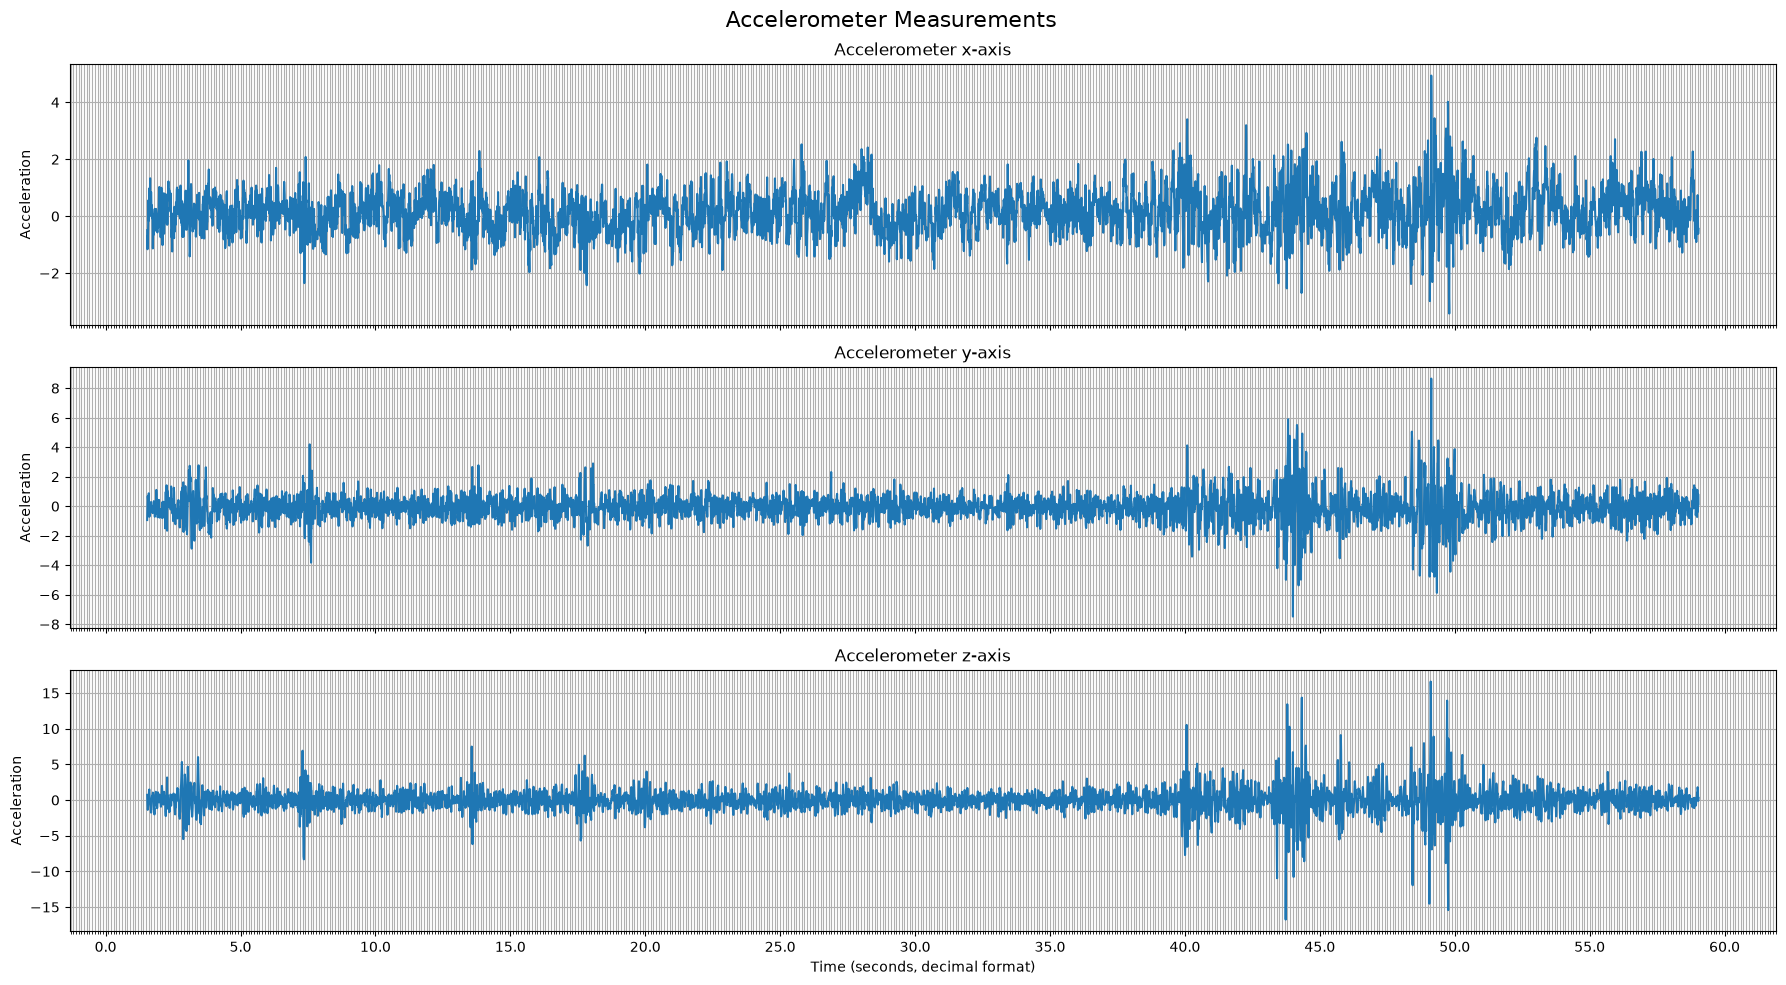

In [19]:
# Plotting script for visualizing the effect of preprocessing steps

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter



# Load one accelerometer recording into a DataFrame
data = pd.read_csv(CUT_OUT_DIR + "/bumpy_stadio/Accelerometer.csv")

# Create one plot for each accelerometer axis
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

for axis, axis_name in zip(axes, ["x", "y", "z"]):
    axis.plot(data["seconds_elapsed"], data[axis_name])
    axis.set_title(f"Accelerometer {axis_name}-axis")
    axis.set_ylabel("Acceleration")
    axis.grid(True, which="both")
    axis.xaxis.set_major_locator(MultipleLocator(5.0))
    axis.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axis.xaxis.set_minor_locator(MultipleLocator(0.1))

axes[-1].set_xlabel("Time (seconds, decimal format)")
fig.suptitle("Accelerometer Measurements", fontsize=16)
fig.tight_layout()
plt.show()
